# MLOps Energy Platform — Prototipo Completo
**Flujo:** Carga → Validación → Preprocesamiento → Entrenamiento → Evaluación → MLflow

Este notebook valida el pipeline completo antes de pasarlo a los microservicios Docker.

## 0. Instalación de dependencias

In [29]:
%pip install pandas numpy scikit-learn mlflow xgboost joblib matplotlib seaborn --quiet

## 1. Configuración global

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import hashlib

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

RAW_PATH     = "/content/sample_data/KAG_energydata_complete.csv"
TARGET_COL   = "consumo_electrodomesticos"
TEST_SIZE    = 0.2
RANDOM_STATE = 42

NUMERICAL_FEATURES   = ["temperatura_sala", "consumo_iluminacion",
                         "temperatura_exterior", "humedad_exterior",
                         "temperatura_meteorologica", "hora", "dia_semana", "mes"]
CATEGORICAL_FEATURES = ["es_fin_de_semana", "rango_termico"]

print("Configuracion lista")

Configuracion lista


## 2. Carga e inspección del dataset

In [60]:
RENAME_MAP = {
    "Appliances" : "consumo_electrodomesticos",
    "lights"     : "consumo_iluminacion",
    "T2"         : "temperatura_sala",
    "T6"         : "temperatura_exterior",
    "RH_out"     : "humedad_exterior",
    "T_out"      : "temperatura_meteorologica",
}

COLS_KEEP = list(RENAME_MAP.keys()) + ["date"]

raw = pd.read_csv(RAW_PATH, parse_dates=["date"])
df  = raw[COLS_KEEP].rename(columns=RENAME_MAP)

df["hora"]             = df["date"].dt.hour
df["dia_semana"]       = df["date"].dt.dayofweek
df["mes"]              = df["date"].dt.month
df["es_fin_de_semana"] = df["date"].dt.dayofweek.isin([5, 6]).astype(int)
df["rango_termico"]    = pd.cut(
    df["temperatura_sala"] - df["temperatura_exterior"],
    bins=[-np.inf, 5, 15, np.inf],
    labels=["Bajo", "Medio", "Alto"]
).astype(str)

df = df.drop(columns=["date"])

print(f"Shape     : {df.shape}")
print(f"Columnas  : {df.columns.tolist()}")
df.head()

Shape     : (19735, 11)
Columnas  : ['consumo_electrodomesticos', 'consumo_iluminacion', 'temperatura_sala', 'temperatura_exterior', 'humedad_exterior', 'temperatura_meteorologica', 'hora', 'dia_semana', 'mes', 'es_fin_de_semana', 'rango_termico']


,consumo_electrodomesticos,consumo_iluminacion,temperatura_sala,temperatura_exterior,humedad_exterior,temperatura_meteorologica,hora,dia_semana,mes,es_fin_de_semana,rango_termico
0,60,30,19.2,7.026667,92.0,6.600000,17,0,1,0,Medio
1,60,30,19.2,6.833333,92.0,6.483333,17,0,1,0,Medio
2,50,30,19.2,6.560000,92.0,6.366667,17,0,1,0,Medio
3,50,40,19.2,6.433333,92.0,6.250000,17,0,1,0,Medio
4,60,40,19.2,6.366667,92.0,6.133333,17,0,1,0,Medio


In [61]:
# Estadísticas descriptivas
df.describe()

,consumo_electrodomesticos,consumo_iluminacion,temperatura_sala,temperatura_exterior,humedad_exterior,temperatura_meteorologica,hora,dia_semana,mes,es_fin_de_semana
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,20.341219,7.910939,79.750418,7.411665,11.502002,2.977249,3.101647,0.277274
std,102.524891,7.935988,2.192974,6.090347,14.901088,5.317409,6.921953,1.985617,1.339200,0.447664
min,10.000000,0.000000,16.100000,-6.065000,24.000000,-5.000000,0.000000,0.000000,1.000000,0.000000
25%,50.000000,0.000000,18.790000,3.626667,70.333333,3.666667,6.000000,1.000000,2.000000,0.000000
50%,60.000000,0.000000,20.000000,7.300000,83.666667,6.916667,12.000000,3.000000,3.000000,0.000000
75%,100.000000,0.000000,21.500000,11.256000,91.666667,10.408333,17.000000,5.000000,4.000000,1.000000
max,1080.000000,70.000000,29.856667,28.290000,100.000000,26.100000,23.000000,6.000000,5.000000,1.000000


In [62]:
# Valores nulos por columna
print("Nulos por columna:")
print(df.isnull().sum())
print(f"\nTotal nulos: {df.isnull().sum().sum()}")

Nulos por columna:
consumo_electrodomesticos    0
consumo_iluminacion          0
temperatura_sala             0
temperatura_exterior         0
humedad_exterior             0
temperatura_meteorologica    0
hora                         0
dia_semana                   0
mes                          0
es_fin_de_semana             0
rango_termico                0
dtype: int64

Total nulos: 0


                           consumo_electrodomesticos  consumo_iluminacion  \
consumo_electrodomesticos                   1.000000             0.197278   
consumo_iluminacion                         0.197278             1.000000   
temperatura_sala                            0.120073            -0.005622   
temperatura_exterior                        0.117638            -0.079029   
humedad_exterior                           -0.152282             0.068543   
temperatura_meteorologica                   0.099155            -0.074424   
es_fin_de_semana                            0.017437            -0.051404   

                           temperatura_sala  temperatura_exterior  \
consumo_electrodomesticos          0.120073              0.117638   
consumo_iluminacion               -0.005622             -0.079029   
temperatura_sala                   1.000000              0.801186   
temperatura_exterior               0.801186              1.000000   
humedad_exterior                  -0.5

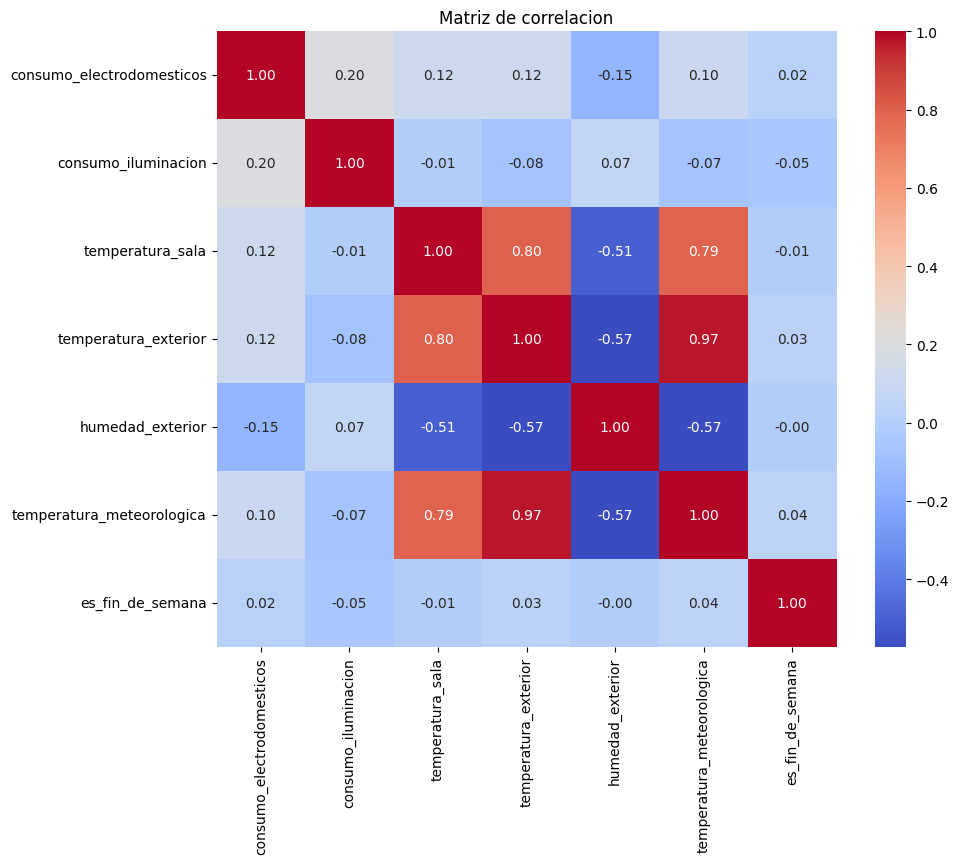

In [63]:
df_num = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = df_num.corr()

print(corr_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de correlacion")
plt.show()

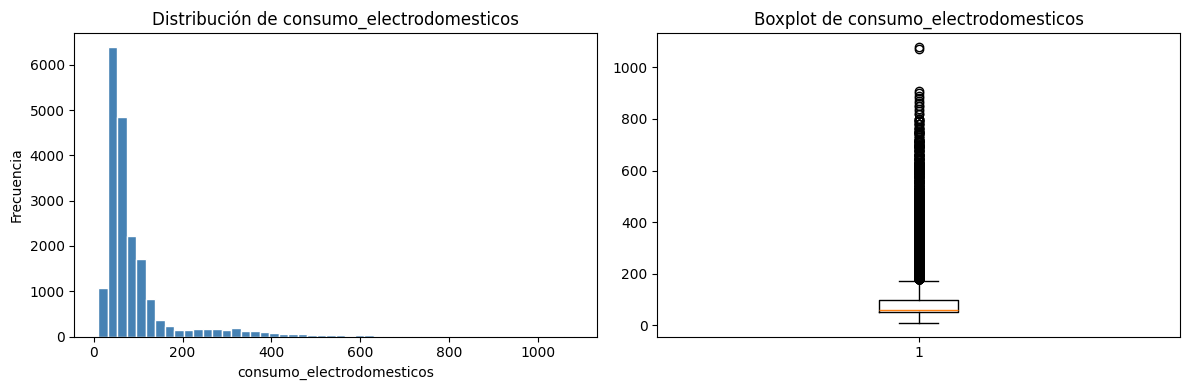

Min  : 10.00
Max  : 1080.00
Media: 97.69


In [64]:
# Distribución del target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df[TARGET_COL], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title(f"Distribución de {TARGET_COL}")
axes[0].set_xlabel("consumo_electrodomesticos")
axes[0].set_ylabel("Frecuencia")

axes[1].boxplot(df[TARGET_COL])
axes[1].set_title(f"Boxplot de {TARGET_COL}")

plt.tight_layout()
plt.show()

print(f"Min  : {df[TARGET_COL].min():.2f}")
print(f"Max  : {df[TARGET_COL].max():.2f}")
print(f"Media: {df[TARGET_COL].mean():.2f}")

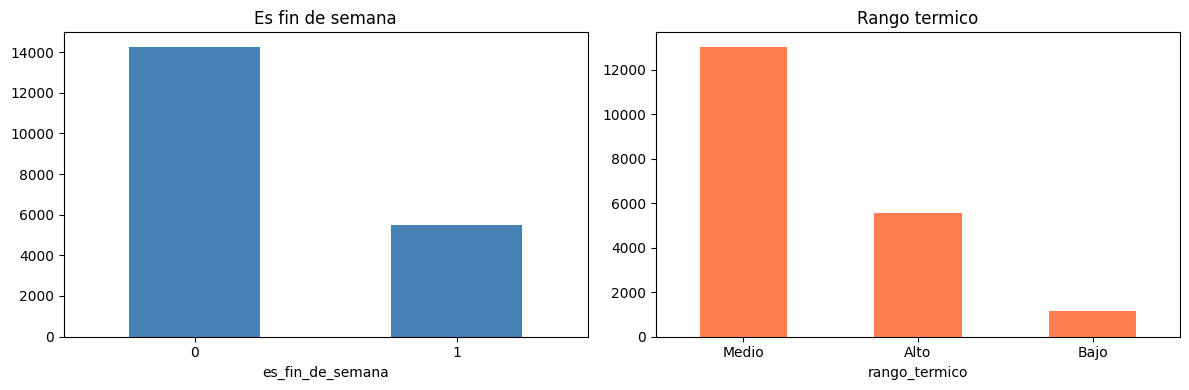

In [65]:
# Distribución de variables categóricas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["es_fin_de_semana"].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title("Es fin de semana")
axes[0].tick_params(axis='x', rotation=0)

df["rango_termico"].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title("Rango termico")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 3. Validación del dataset

In [66]:
errors = []

# Cantidad mínima de filas
if len(df) < 100:
    errors.append(f"Pocas filas: {len(df)}")

# Columnas requeridas
required = NUMERICAL_FEATURES + CATEGORICAL_FEATURES + [TARGET_COL]
missing  = [c for c in required if c not in df.columns]
if missing:
    errors.append(f"Columnas faltantes: {missing}")

# Nulos excesivos (> 5%)
null_pct = df.isnull().mean()
excess   = null_pct[null_pct > 0.05].index.tolist()
if excess:
    errors.append(f"Columnas con >5% nulos: {excess}")

# Valores negativos en target
negatives = (df[TARGET_COL] < 0).sum()
if negatives > 0:
    errors.append(f"{negatives} filas con {TARGET_COL} negativo")

if errors:
    print("VALIDACION FALLIDA:")
    for e in errors:
        print(f"  x {e}")
else:
    print(f"Validacion OK")
    print(f"  Filas    : {len(df)}")
    print(f"  Columnas : {list(df.columns)}")
    print(f"  Target   : min={df[TARGET_COL].min():.2f} | max={df[TARGET_COL].max():.2f} | media={df[TARGET_COL].mean():.2f}")

Validacion OK
  Filas    : 19735
  Columnas : ['consumo_electrodomesticos', 'consumo_iluminacion', 'temperatura_sala', 'temperatura_exterior', 'humedad_exterior', 'temperatura_meteorologica', 'hora', 'dia_semana', 'mes', 'es_fin_de_semana', 'rango_termico']
  Target   : min=10.00 | max=1080.00 | media=97.69


## 4. Preprocesamiento

In [67]:
# 4.1 Limpieza
filas_inicial = len(df)
df = df.dropna()
df = df[df[TARGET_COL] > 0]
print(f"Limpieza: {filas_inicial} -> {len(df)} filas ({filas_inicial - len(df)} eliminadas)")

Limpieza: 19735 -> 19735 filas (0 eliminadas)


In [68]:
# Encoding de variables categóricas
le = LabelEncoder()

df["es_fin_de_semana_enc"] = le.fit_transform(df["es_fin_de_semana"])
df["rango_termico_enc"]    = le.fit_transform(df["rango_termico"])

FEATURE_COLS = NUMERICAL_FEATURES + ["es_fin_de_semana_enc", "rango_termico_enc"]

X = df[FEATURE_COLS]
y = df[TARGET_COL]

print(f"Features : {FEATURE_COLS}")
print(f"Target   : {TARGET_COL}")
print(f"X shape  : {X.shape}")
print(f"y shape  : {y.shape}")

Features : ['temperatura_sala', 'consumo_iluminacion', 'temperatura_exterior', 'humedad_exterior', 'temperatura_meteorologica', 'hora', 'dia_semana', 'mes', 'es_fin_de_semana_enc', 'rango_termico_enc']
Target   : consumo_electrodomesticos
X shape  : (19735, 10)
y shape  : (19735,)


In [77]:
# Split temporal — sin shuffle para respetar el orden cronológico
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True
)

print(f"Train : {X_train.shape} | Test : {X_test.shape}")

Train : (15788, 10) | Test : (3947, 10)


In [78]:
# Normalización (fit solo en train)
scaler = MinMaxScaler()

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[NUMERICAL_FEATURES] = scaler.fit_transform(X_train[NUMERICAL_FEATURES])
X_test_scaled[NUMERICAL_FEATURES]  = scaler.transform(X_test[NUMERICAL_FEATURES])

X_train_scaled = X_train_scaled.reset_index(drop=True)
X_test_scaled  = X_test_scaled.reset_index(drop=True)
y_train        = y_train.reset_index(drop=True)
y_test         = y_test.reset_index(drop=True)

print("Normalizacion aplicada")
X_train_scaled.head()

Normalizacion aplicada


,temperatura_sala,consumo_iluminacion,temperatura_exterior,humedad_exterior,temperatura_meteorologica,hora,dia_semana,mes,es_fin_de_semana_enc,rango_termico_enc
0,0.225345,0.0,0.499126,0.809211,0.491961,0.521739,0.166667,0.00,0,2
1,0.711655,0.0,0.898213,0.416667,0.891747,0.739130,0.666667,1.00,0,1
2,0.394960,0.0,0.365967,0.526316,0.372990,0.565217,0.333333,0.25,0,0
3,0.079961,0.0,0.256993,0.925439,0.228296,0.391304,0.833333,0.50,1,2
4,0.072692,0.0,0.156274,0.899123,0.132905,0.173913,1.000000,0.50,1,0


## 5. Entrenamiento

In [79]:
def evaluate(y_true, y_pred) -> dict:
    return {
        "mae" : round(mean_absolute_error(y_true, y_pred), 4),
        "rmse": round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
        "r2"  : round(r2_score(y_true, y_pred), 4)
    }


def train(model, model_name: str, params: dict) -> dict:

    model.fit(X_train_scaled, y_train)
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test  = model.predict(X_test_scaled)

    train_metrics = evaluate(y_train, y_pred_train)
    test_metrics  = evaluate(y_test,  y_pred_test)

    print(f"\n{model_name}")
    print(f"  Train -> MAE: {train_metrics['mae']} | RMSE: {train_metrics['rmse']} | R2: {train_metrics['r2']}")
    print(f"  Test  -> MAE: {test_metrics['mae']}  | RMSE: {test_metrics['rmse']}  | R2: {test_metrics['r2']}")

    return {
        "model_name"  : model_name,
        "model"       : model,
        **{f"test_{k}": v for k, v in test_metrics.items()}
    }

print("Funciones de entrenamiento listas")

Funciones de entrenamiento listas


In [80]:
# ----------------------------------------------------
# Modelo 1 — Regresión Lineal (baseline)
# ----------------------------------------------------
result_lr = train(
    model      = LinearRegression(),
    model_name = "LinearRegression",
    params     = {"fit_intercept": True}
)


LinearRegression
  Train -> MAE: 55.4022 | RMSE: 98.2377 | R2: 0.0927
  Test  -> MAE: 54.3553  | RMSE: 94.8529  | R2: 0.1009


In [81]:
# ----------------------------------------------------
# Modelo 2 — Random Forest
# ----------------------------------------------------
result_rf = train(
    model      = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE),
    model_name = "RandomForest",
    params     = {"n_estimators": 100, "random_state": RANDOM_STATE}
)


RandomForest
  Train -> MAE: 12.5996 | RMSE: 26.4484 | R2: 0.9342
  Test  -> MAE: 32.2636  | RMSE: 67.6315  | R2: 0.5429


In [85]:
# ----------------------------------------------------
# Modelo 3 — XGBoost
# ----------------------------------------------------
result_xgb = train(
    model      = XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=RANDOM_STATE, verbosity=0),
    model_name = "XGBoost",
    params     = {"n_estimators": 300, "learning_rate": 0.05, "random_state": RANDOM_STATE}
)


XGBoost
  Train -> MAE: 34.7244 | RMSE: 65.1831 | R2: 0.6005
  Test  -> MAE: 39.9086  | RMSE: 75.5697  | R2: 0.4293


## 6. Comparación de modelos

In [86]:
comparison_df = pd.DataFrame([
    {"Modelo": r["model_name"], "MAE": r["test_mae"], "RMSE": r["test_rmse"], "R2": r["test_r2"]}
    for r in [result_lr, result_rf, result_xgb]
])

print("Comparacion de modelos (test set):")
comparison_df

Comparacion de modelos (test set):


,Modelo,MAE,RMSE,R2
0,LinearRegression,54.3553,94.8529,0.1009
1,RandomForest,32.2636,67.6315,0.5429
2,XGBoost,39.9086,75.5697,0.4293


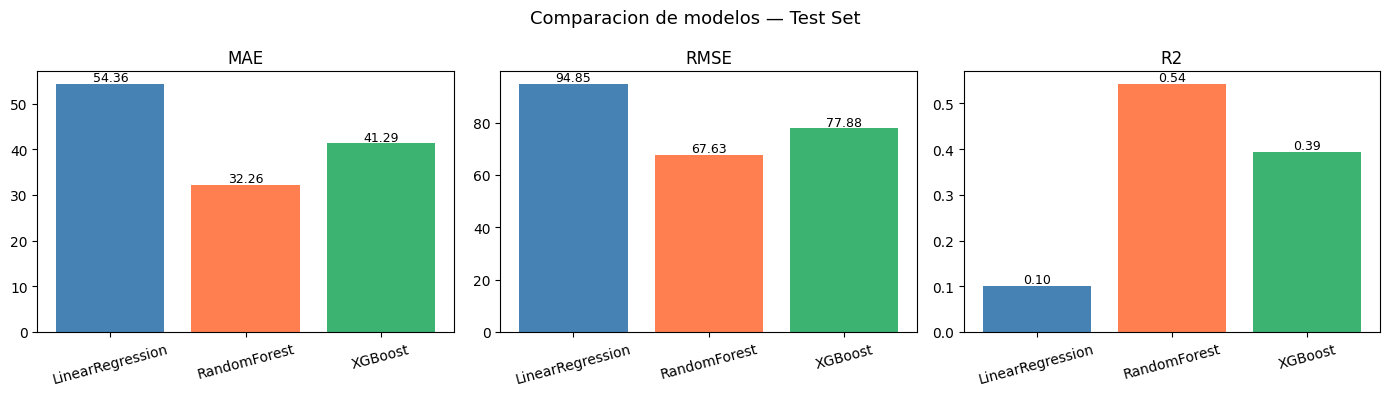

In [84]:
# Gráfico de comparación
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics   = ["MAE", "RMSE", "R2"]
colors    = ["steelblue", "coral", "mediumseagreen"]

for i, metric in enumerate(metrics):
    axes[i].bar(comparison_df["Modelo"], comparison_df[metric], color=colors)
    axes[i].set_title(metric)
    axes[i].tick_params(axis='x', rotation=15)
    for j, v in enumerate(comparison_df[metric]):
        axes[i].text(j, v + max(comparison_df[metric])*0.01, f"{v:.2f}", ha='center', fontsize=9)

plt.suptitle("Comparacion de modelos — Test Set", fontsize=13)
plt.tight_layout()
plt.show()